# Natural Language Processing Pipeline Project

## Objective

The goal of the project is to leverage exsiting customers reviews data to determine if they recommend the product to build a predictive model that will suggest if the recommendation data is empty.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

In [2]:
# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Project

## Data Exploration

In [5]:
#understanding dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


In [6]:
# summary stats for categorical variables
df.describe(include="object")

,Title,Review Text,Division Name,Department Name,Class Name
count,18442,18442,18442,18442,18442
unique,13142,18439,2,6,14
top,Love it!,The sweater and skirt are so pretty! they're r...,General,Tops,Dresses
freq,129,2,11664,8713,5371


In [7]:
# summary stats for numerical variables
df[['Age', 'Positive Feedback Count']].describe()

,Age,Positive Feedback Count
count,18442.000000,18442.000000
mean,43.383635,2.697484
std,12.246264,5.942220
min,18.000000,0.000000
25%,34.000000,0.000000
50%,41.000000,1.000000
75%,52.000000,3.000000
max,99.000000,122.000000


In [8]:
#duplicate detection
df.duplicated().sum()

np.int64(0)

In [9]:
#unique values
df['Recommended IND'].value_counts()

Recommended IND
1    15053
0     3389
Name: count, dtype: int64

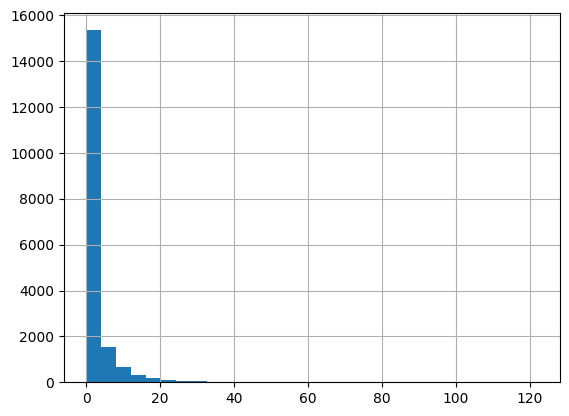

In [10]:
#distribution analysis
df["Positive Feedback Count"].hist(bins=30)
plt.show()

<Axes: ylabel='Density'>

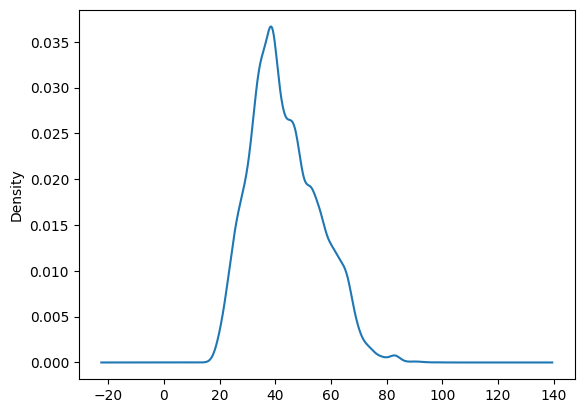

In [11]:
df["Age"].plot(kind="density")

Based on the initial data exploration, the dataset appears to be clean and does not require any further data cleaning.

## Building Pipeline

In [12]:
# split data into numerical, categorical, and text features

num_features = (
    X[[
        'Age',
        'Positive Feedback Count'
    ]].columns
)
print('Numerical features:', num_features)


cat_features = (
    X[[
        'Division Name',
        'Department Name',
        'Class Name'
    ]].columns
)
print('Categorical features:', cat_features)


text_features = (
    X[[
        'Title',
        'Review Text'
    ]].columns
)
print ('Review Text features:', text_features)

Numerical features: Index(['Age', 'Positive Feedback Count'], dtype='object')
Categorical features: Index(['Division Name', 'Department Name', 'Class Name'], dtype='object')
Review Text features: Index(['Title', 'Review Text'], dtype='object')


In [13]:
# pipeline for numerical features
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='mean'),
    ),
    (
        'scaler',
        MinMaxScaler(),
    ),
])

num_pipeline

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', MinMaxScaler())])

In [14]:
#checking the output of the numerical feature pipeline
X_train_num = num_pipeline.fit_transform(X_train[['Age','Positive Feedback Count']])
X_train_num

array([[0.2345679 , 0.01639344],
       [0.0617284 , 0.        ],
       [0.28395062, 0.08196721],
       ...,
       [0.39506173, 0.01639344],
       [0.20987654, 0.10655738],
       [0.39506173, 0.        ]])

## Categorical Features Pipeline

In [15]:
# pipeline for categorical features
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([  
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
        )
    ),
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        )
    ),
])

cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('cat_encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [16]:
#checking the output of the categorical feature pipeline
X_train_cat = cat_pipeline.fit_transform(X_train[['Division Name','Department Name','Class Name']])
X_train_cat

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 1., ..., 1., 0., 0.]])

## Text Feature Pipeline

In [17]:
!python -m spacy download en_core_web_sm

/System/Library/Frameworks/Python.framework/Versions/2.7/Resources/Python.app/Contents/MacOS/Python: No module named spacy


In [18]:
# building SpacyLemmatizer() to lemmatize the text given
from sklearn.base import BaseEstimator, TransformerMixin
import spacy
nlp = spacy.load('en_core_web_sm')

class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized  

In [19]:
#checking output of SpacyLemmatizer
lemmatizer = SpacyLemmatizer(nlp)
X_train_lemma = lemmatizer.fit_transform(X_train['Review Text'])
X_train_lemma

['easy fun jumper . run slightly large . order medium return small . dress variety occasion . perfect pocket .',
 "dress look great winter summer , pair tight light jacket . run true size -- able buy online . fabric great day wear -- doesn't wrinkle . \n\n con dart breast little pointy taste , love dress .",
 'want love dress perfect spring summer , work . feel bit frumpy , honestly . purchase neutral color . maybe " red " ... grandmotherly . elastic waist work . try boot , booty , heel , clog , flat , sandal dress work . sadly send . 5\'7 " , 140 lbs try medium .',
 'love shirt purchase shrink badly seam ( ) crook . long receipt sure return it~ sigh . love pilcro chino buy !',
 'review purchase review receive dress appal positive review ! ! ! dress hideous person . seriously hideous . past drapery fabric , incredibly restricting . picture online misleading . dress ivory pea green ! disappointed .',
 'say , pretty person . beautifully , color pretty . unique special . sweater size smal

In [20]:
#comparing original with lemmatized "Review Text"
for original, lemma in zip(
    X_train['Review Text'].head(),
    X_train_lemma[:5]
):
    print("Original:", original)
    print("Lemmatized:", lemma)
    print("-" * 80)

Original: Easy and fun jumper. runs slightly large. i ordered a medium and returned for a small. can be dressed up or down for a variety of occasions. would be perfect if it had pockets.
Lemmatized: easy fun jumper . run slightly large . order medium return small . dress variety occasion . perfect pocket .
--------------------------------------------------------------------------------
Original: The dress looks great both in winter and summer, either paired with tights and a light jacket or on its own. it runs true to size--was able to buy it online. the fabric is great for all day wear--doesn't wrinkle too much.

the only con is that the darts over the breasts are a little pointy for my taste, but i still love the dress.
Lemmatized: dress look great winter summer , pair tight light jacket . run true size -- able buy online . fabric great day wear -- doesn't wrinkle . 

 con dart breast little pointy taste , love dress .
-----------------------------------------------------------------

In [21]:
#tfidf pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipeline = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
    (
        'lemmatizer',
        SpacyLemmatizer(nlp=nlp),
    ),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
        ),
    ),
])
tfidf_pipeline 

Pipeline(steps=[('dimension_reshaper',
                 FunctionTransformer(func=<function reshape at 0x10d5b03f0>,
                                     kw_args={'newshape': -1})),
                ('lemmatizer',
                 SpacyLemmatizer(nlp=<spacy.lang.en.English object at 0x136230790>)),
                ('tfidf_vectorizer', TfidfVectorizer(stop_words='english'))])

In [22]:
# building SpacyNER() to find named entity recognition
class SpacyNER(BaseEstimator, TransformerMixin):

    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        return [
            " ".join(ent.label_ for ent in doc.ents)
            for doc in self.nlp.pipe(X)
        ]

In [23]:
#checking output of SpacyNER
ner = SpacyNER(nlp)
X_train_ner = ner.fit_transform(X_train['Review Text'])
X_train_ner

['',
 'DATE DATE',
 'DATE DATE CARDINAL CARDINAL CARDINAL',
 '',
 '',
 '',
 'CARDINAL WORK_OF_ART DATE',
 '',
 'GPE MONEY CARDINAL',
 '',
 'CARDINAL ORG CARDINAL',
 'CARDINAL',
 '',
 'CARDINAL DATE ORG DATE',
 '',
 '',
 'CARDINAL',
 'CARDINAL',
 '',
 'CARDINAL CARDINAL CARDINAL',
 '',
 'DATE',
 'CARDINAL',
 'DATE',
 '',
 'DATE',
 'DATE CARDINAL',
 'CARDINAL CARDINAL CARDINAL CARDINAL CARDINAL MONEY MONEY DATE CARDINAL ORDINAL',
 'DATE',
 'DATE CARDINAL',
 'CARDINAL DATE',
 '',
 'CARDINAL MONEY',
 '',
 '',
 'DATE DATE',
 'DATE DATE',
 'CARDINAL CARDINAL ORDINAL MONEY',
 '',
 'GPE',
 'CARDINAL QUANTITY',
 'CARDINAL DATE CARDINAL',
 'CARDINAL CARDINAL DATE',
 'ORDINAL',
 'CARDINAL',
 'QUANTITY QUANTITY CARDINAL CARDINAL',
 'DATE DATE',
 '',
 '',
 'CARDINAL CARDINAL CARDINAL',
 '',
 '',
 'CARDINAL',
 'DATE ORDINAL DATE',
 'ORDINAL',
 'QUANTITY CARDINAL',
 'DATE DATE CARDINAL',
 'DATE',
 '',
 'DATE CARDINAL',
 'TIME',
 'CARDINAL',
 'DATE CARDINAL DATE',
 '',
 'QUANTITY',
 '',
 '',
 'DATE DA

In [24]:
#NER pipeline
from sklearn.feature_extraction.text import CountVectorizer

ner_pipeline = Pipeline([
    ('reshape',
     FunctionTransformer(np.ravel, validate=False)),
    ('ner',
     SpacyNER(nlp)),
    ('count',
     CountVectorizer())
])

# Combine Feature Engineering Pipelines

In [25]:
from sklearn.compose import ColumnTransformer

feature_engineering = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),

    ('title_tfidf', tfidf_pipeline, 'Title'),
    ('review_tfidf', tfidf_pipeline, 'Review Text'),

    ('title_ner', ner_pipeline, 'Title'),
    ('review_ner', ner_pipeline, 'Review Text')
])

## Training Pipeline

### Train Model

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

model_pipeline = make_pipeline(
    feature_engineering,
    RandomForestClassifier(random_state=27),
)

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False...
                                                                   SpacyNER(nlp=<spacy.lang.en.English object at 0x136230790>)),
                                                                  ('count',
                                                                   CountVectorizer())]),
                                                  'Title'),
                                                 ('review_ner',
                                                  Pipeline(steps=[('reshape',
                                                                   FunctionTransformer(func=<function ravel at 0x10d5b3830>)),
                                                                  ('ner',
                                                                   SpacyNER(nlp=<spacy.lang.en.English object at 0x136230790>)),
                                                                  ('count',
                                                                   CountVectorizer())]),
                                                  'Review Text')])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=27))])

### Evaluate Model

In [27]:
from sklearn.metrics import accuracy_score

y_pred_forest_pipeline = model_pipeline.predict(X_test)
accuracy_forest_pipeline = accuracy_score(y_test, y_pred_forest_pipeline)

print('Accuracy:', accuracy_forest_pipeline)

Accuracy: 0.8542005420054201


## Fine-Tuning Pipeline

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "randomforestclassifier__max_features": [100, 150],
    "randomforestclassifier__n_estimators": [150, 200],
}

search = GridSearchCV(
    model_pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=3,
)
search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV 2/3] END randomforestclassifier__max_features=100, randomforestclassifier__n_estimators=200;, score=0.858 total time=74.8min
[CV 3/3] END randomforestclassifier__max_features=100, randomforestclassifier__n_estimators=200;, score=0.851 total time=74.9min
[CV 1/3] END randomforestclassifier__max_features=150, randomforestclassifier__n_estimators=150;, score=0.864 total time=74.7min
[CV 2/3] END randomforestclassifier__max_features=150, randomforestclassifier__n_estimators=150;, score=0.862 total time=74.7min
[CV 1/3] END randomforestclassifier__max_features=100, randomforestclassifier__n_estimators=150;, score=0.857 total time=74.1min
[CV 3/3] END randomforestclassifier__max_features=150, randomforestclassifier__n_estimators=150;, score=0.861 total time=14.9min
[CV 2/3] END randomforestclassifier__max_features=100, randomforestclassifier__n_estimators=150;, score=0.857 total time=74.3min
[CV 1/3] END randomforestclassifier__

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('cat_encoder',
                                                                                          OneHotEncoder(handle_unknown=...
                                                                                          FunctionTransformer(func=<function ravel at 0x10d5b3830>)),
                                                                                         ('ner',
                                                                                          SpacyNER(nlp=<spacy.lang.en.English object at 0x136230790>)),
                                                                                         ('count',
                                                                                          CountVectorizer())]),
                                                                         'Review '
                                                                         'Text')])),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=27))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_features': [100, 150],
                         'randomforestclassifier__n_estimators': [150, 200]},
             verbose=3)

In [29]:
model_best = search.best_estimator_
model_best

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False...
                                                                  ('count',
                                                                   CountVectorizer())]),
                                                  'Title'),
                                                 ('review_ner',
                                                  Pipeline(steps=[('reshape',
                                                                   FunctionTransformer(func=<function ravel at 0x10d5b3830>)),
                                                                  ('ner',
                                                                   SpacyNER(nlp=<spacy.lang.en.English object at 0x1657d7ed0>)),
                                                                  ('count',
                                                                   CountVectorizer())]),
                                                  'Review Text')])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_features=150, n_estimators=200,
                                        random_state=27))])

In [30]:
y_pred_forest_pipeline = model_best.predict(X_test)
accuracy_forest_pipeline = accuracy_score(y_test, y_pred_forest_pipeline)

print('Accuracy:', accuracy_forest_pipeline)

Accuracy: 0.8607046070460704
